## svhn街道门牌号识别
> [svhn](http://ufldl.stanford.edu/housenumbers/)官网下载format2，放在`DL/data/svhn`中  

把数据给抽样一遍，可以发现标签有很多问题：其门牌号的位数很多大于1位（例如门牌号112，是3位），但其标签要么显示10，要么显示其中的某一位（例如，23的标签是10，64的标签是6）。这就说明我们在训练数据前，需要将这些标签错误的数据给尽可能排除掉。对于标签为10的数据，我们可以利用if语句给识别出来，但后一种情况，就只能当做噪点来处理了。

In [1]:
import os

workspace = os.getcwd()     # c:\piao_programs\py_programs\DeepLearningProject\DL
svhn_dir = os.path.join(workspace, "data\\svhn")
print(f"workspace: {workspace}\nsvhn: {svhn_dir}")

workspace: c:\piao_programs\py_programs\DeepLearningProject\DL
svhn: c:\piao_programs\py_programs\DeepLearningProject\DL\data\svhn


In [2]:
import numpy as np
from scipy.io import loadmat as load

#-----------------------------------
#            数据处理
#-----------------------------------

# 1. 数据读取
svhn_test = os.path.join(workspace, "data\\svhn\\test_32x32.mat")
svhn_train = os.path.join(workspace, "data\\svhn\\train_32x32.mat")
# 加载数据
train_data = load(svhn_train)
test_data = load(svhn_test)
x_train, y_train = train_data['X'].transpose(3, 0, 1, 2), train_data['y'][:,0]
x_test, y_test = test_data['X'].transpose(3, 0, 1, 2), test_data['y'][:,0]

print(f"train: x: {x_train.shape}, y: {y_train.shape}")
print(f"test: x: {x_test.shape}, y: {y_test.shape}")



# 2. 数据清洗(删除错误标签)
# mask_train = y_train != 10
# mask_test = y_test != 10

# x_train_clean = x_train[mask_train]
# y_train_clean = y_train[mask_train]
# x_test_clean = x_test[mask_test]
# y_test_clean = y_test[mask_test]

# 2.将标签10转换为数据0
y_train[y_train == 10] = 0
y_test[y_test == 10] = 0

x_train_clean = x_train
y_train_clean = y_train 
x_test_clean = x_test
y_test_clean = y_test

# 将标签转化为one-hot编码
y_train_one_hot = np.eye(10)[y_train_clean]
y_test_one_hot = np.eye(10)[y_test_clean]

# 可以打印清洗后数据形状检查
print(f"Clean Train: x: {x_train_clean.shape}, y: {y_train_clean.shape}, one-hot: {y_train_one_hot.shape}")
print(f"Clean Test: x: {x_test_clean.shape}, y: {y_test_clean.shape}, one-hot: {y_test_one_hot.shape}")


train: x: (73257, 32, 32, 3), y: (73257,)
test: x: (26032, 32, 32, 3), y: (26032,)
Clean Train: x: (73257, 32, 32, 3), y: (73257,), one-hot: (73257, 10)
Clean Test: x: (26032, 32, 32, 3), y: (26032,), one-hot: (26032, 10)


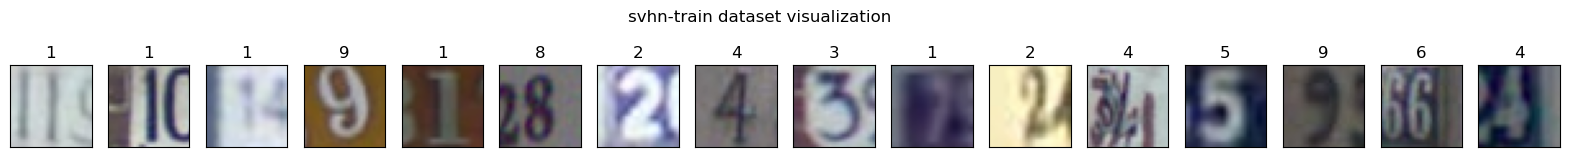

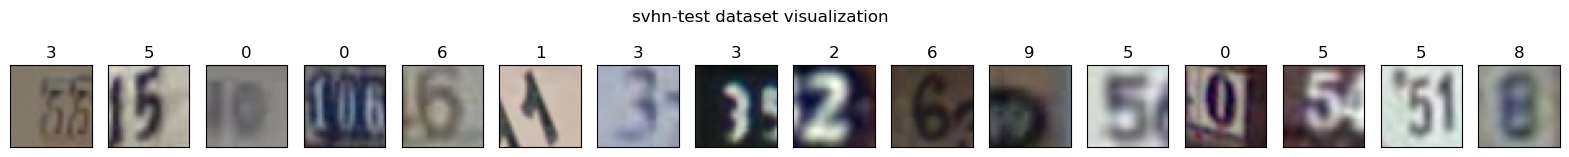

In [3]:
import matplotlib.pyplot as plt
# import numpy as np

# ploting svhn image in n rows and m columns for grayscale ans rgb both
def show(imgs, labels,n ,m, category):
    fig, axes = plt.subplots(n, m, figsize=(20, 2))
    for i, ax in enumerate(axes.flat):
        if imgs[i].shape == (32, 32, 3):
            ax.imshow(imgs[i])
        else:
            raise Exception(f"img shape: {imgs[i].shape}")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(labels[i])
    fig.suptitle(f"svhn-{category} dataset visualization")
    plt.show()


indices = np.random.choice(x_train_clean.shape[0], size=16, replace=False)
selected_x_train = x_train_clean[indices]
selected_y_train = y_train_clean[indices]

show(selected_x_train, selected_y_train, 1, 16, "train")

# 对于测试集同样操作
indices = np.random.choice(x_test_clean.shape[0], size=16, replace=False)
selected_x_test = x_test_clean[indices]
selected_y_test = y_test_clean[indices]

show(selected_x_test, selected_y_test, 1, 16, "test")

# 显示之前的标签为10的图片
# l_10 = y_train == 10
# imgs = x_train[l_10]
# labeled_10 = y_train[l_10]
# indices = np.random.choice(imgs.shape[0], size=16, replace=False)
# selected_x_10 = imgs[indices]
# selected_y_10 = labeled_10[indices]

# print(labeled_10)
# show(selected_x_10, selected_y_10, 1, 16, "label_10")

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


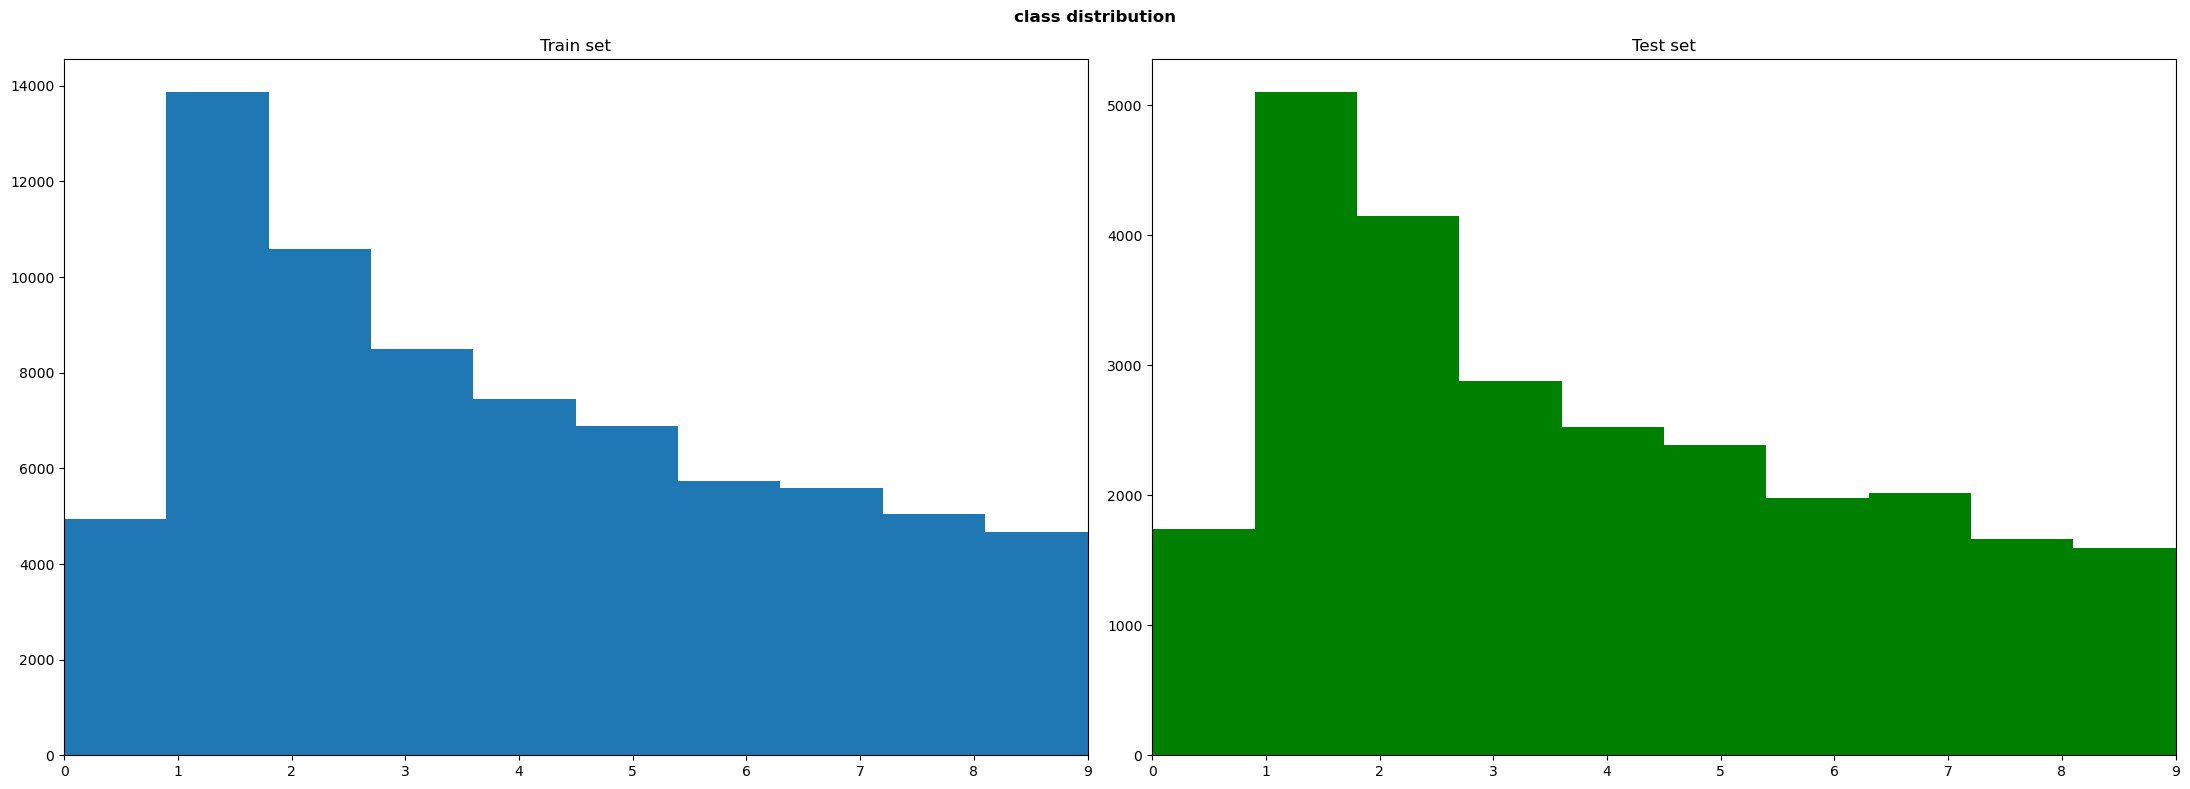

In [4]:
# 显示标签
print(np.unique(y_train_clean))
print(np.unique(y_test_clean))

# 数据分布
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, figsize=(22, 8))
fig.suptitle("class distribution", fontweight='bold')

ax1.hist(y_train_clean, bins=10)
ax1.set_title("Train set")
ax1.set_xlim(0, 9)

ax2.hist(y_test_clean, color='g', bins=10)
ax2.set_title("Test set")

fig.tight_layout()


- rgb to gray
$$Y = 0.2990R + 0.5870G + 0.1140B$$
这里用的resnet默认支持rgb3通道输入，在此不做转换，仅进行归一化。

In [5]:
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.utils.data import Dataset

# -----------------------------
#   拆分数据集
# -----------------------------

NUM_LABELED = int(len(x_train_clean) * 0.1)

# 归一化
labeled_images = x_train_clean[:NUM_LABELED]
labeled_labels = y_train_clean[:NUM_LABELED]
unlabeled_images = x_train_clean[NUM_LABELED:]
unlabeled_labels = y_train_clean[NUM_LABELED:]

print(f"带标签数据：{len(labeled_images)}")
print(f"无标签数据：{len(unlabeled_images)}")

带标签数据：7325
无标签数据：65932


In [6]:
# ----------------------------
#       创建dataloader
# ----------------------------

class LabeledCIFARDataset(Dataset):
    """
    带标签数据集
    """
    def __init__(self, images, labels, transform=None):
        """
        有标签数据集
        """
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx]
        y = self.labels[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

class UnlabeledCIFARDataset(Dataset):
    def __init__(self, images, transform=None):
        """
        无标签数据集
        """
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx]
        if self.transform:
            x = self.transform(x)
        return x

class CIFARValDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        """
        验证/测试数据集
        """
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx]
        y = self.labels[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

BATCH_SIZE = 64

mean = [0.43768454, 0.44376847, 0.4728039]
std = [0.19803019, 0.20101567, 0.19703582]

transform = transforms.Compose([
    transforms.Normalize(mean, std)
])

# 有标签 DataLoader
labeled_dataset = LabeledCIFARDataset(labeled_images, labeled_labels, transform)
labeled_loader = DataLoader(
    labeled_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

# 无标签 DataLoader
unlabeled_dataset = UnlabeledCIFARDataset(unlabeled_images, transform)
unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

# 验证/测试 DataLoader
val_dataset = CIFARValDataset(x_test_clean, y_test_clean)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"有标签数据批次数: {len(labeled_loader)}")
print(f"无标签数据批次数: {len(unlabeled_loader)}")
print(f"验证/测试数据批次数: {len(val_loader)}")

有标签数据批次数: 114
无标签数据批次数: 1030
验证/测试数据批次数: 407


In [ ]:
import torch
from torch import nn, optim
from itertools import cycle

from models.resnet_kaming import ResNet34, ResNet50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   # 设备类型
print(f"device: {device}")

resnet34 = ResNet34(num_class=10).to(device=device)   # 初始化模型
resnet50 = ResNet50(num_class=10).to(device=device)   # 初始化模型

def evaluate_on_val(model, test_loader):
    """
    评估
    """
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x_val, y_val in test_loader:
            x_val = x_val.to(device)
            y_val = y_val.to(device)

            output = model.forward(x_val)

            pres = torch.argmax(output, dim=1)
            correct += (pres == y_val).sum().item()
            total += y_val.size(0)
    acc = correct / total
    return acc

def train_semi_supervised(model, labeled_loader, unlabeled_loader, val_loader, epochs=20, lr=1e-1):
    """
    半监督训练
    Args:
        model: 模型
        labeled_loader: 带标签样本
        unlabeled_loader: 无标签样本
        val_loader: 测试样本
        epochs: 训练批次
        lr: 学习率
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    cross_entropy_loss = nn.CrossEntropyLoss()      # 交叉熵损失

